# VR Emotion Study - Data Exploration

This notebook loads `weights.csv` files from one recording session and checks whether the collected XR tracking data is usable for analysis or model training.

Expected folder shape:

```text
VideoRecordings/
  20260521-1048/
    Anger/
      weights.csv
    Disgust/
      weights.csv
```


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

# Change this if you analyze a different copied session.
SESSION_ROOT = Path(r"C:\Users\alime\multimodal-vr-emotion-study\multimodal-vr-emotion-study-main\VideoRecordings\VideoRecordings\20260128-0826")

print(SESSION_ROOT)
print("Exists:", SESSION_ROOT.exists())


C:\Users\alime\multimodal-vr-emotion-study\multimodal-vr-emotion-study-main\VideoRecordings\VideoRecordings\20260128-0826
Exists: True


## Load All Emotion CSV Files

Each emotion folder should contain one `weights.csv`. We load every available file and add `SourceEmotion` and `SourceFile` columns so we can trace every row back to its folder.


In [2]:
csv_files = sorted(SESSION_ROOT.glob("*/weights.csv"))
print(f"Found {len(csv_files)} weights.csv files")

frames = []
for csv_file in csv_files:
    emotion = csv_file.parent.name
    frame = pd.read_csv(csv_file)
    frame["SourceEmotion"] = emotion
    frame["SourceFile"] = str(csv_file)
    frames.append(frame)

if not frames:
    raise FileNotFoundError(f"No weights.csv files found under {SESSION_ROOT}")

df = pd.concat(frames, ignore_index=True)
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns):,}")
df.head()


Found 2 weights.csv files
Total rows: 364
Total columns: 96


,Timestamp,RealtimeSeconds,Emotion,HeadTracked,HeadX,HeadY,HeadZ,LeftHandTracked,LeftHandX,LeftHandY,LeftHandZ,RightHandTracked,RightHandX,RightHandY,RightHandZ,LeftControllerTracked,LeftControllerX,LeftControllerY,LeftControllerZ,RightControllerTracked,RightControllerX,RightControllerY,RightControllerZ,FaceValid,BrowLowererL,BrowLowererR,CheekPuffL,CheekPuffR,CheekRaiserL,CheekRaiserR,CheekSuckL,CheekSuckR,ChinRaiserB,ChinRaiserT,DimplerL,DimplerR,EyesClosedL,EyesClosedR,EyesLookDownL,EyesLookDownR,EyesLookLeftL,EyesLookLeftR,EyesLookRightL,EyesLookRightR,EyesLookUpL,EyesLookUpR,InnerBrowRaiserL,InnerBrowRaiserR,JawDrop,JawSidewaysLeft,JawSidewaysRight,JawThrust,LidTightenerL,LidTightenerR,LipCornerDepressorL,LipCornerDepressorR,LipCornerPullerL,LipCornerPullerR,LipFunnelerLB,LipFunnelerLT,LipFunnelerRB,LipFunnelerRT,LipPressorL,LipPressorR,LipPuckerL,LipPuckerR,LipStretcherL,LipStretcherR,LipSuckLB,LipSuckLT,LipSuckRB,LipSuckRT,LipTightenerL,LipTightenerR,LipsToward,LowerLipDepressorL,LowerLipDepressorR,MouthLeft,MouthRight,NoseWrinklerL,NoseWrinklerR,OuterBrowRaiserL,OuterBrowRaiserR,UpperLidRaiserL,UpperLidRaiserR,UpperLipRaiserL,UpperLipRaiserR,TongueTipInterdental,TongueTipAlveolar,TongueFrontDorsalPalate,TongueMidDorsalPalate,TongueBackDorsalVelar,TongueOut,TongueRetreat,SourceEmotion,SourceFile
0,24.161837,25.419151,Neutral,1,-0.538189,1.197362,1.124503,0,0.0,0.0,0.0,1,-0.488739,0.933904,1.346040,0,0,0,0,0,0,0,0,1,2.645961e-07,0.010802,0.0,0.0,0.051045,0.023418,0.0,0.0,2.741568e-19,1.922553e-09,2.266690e-12,1.027665e-12,0.0,3.485130e-12,3.130948e-19,3.485130e-12,0.0,0.0,0.270413,0.182786,0,0,0.001826,0.003217,0.027164,0.0,4.353665e-14,0.0,0.022465,0.011084,0.011050,0.010866,2.740595e-14,2.796259e-12,0.0,0.0,0.0,0.0,4.223640e-18,3.409666e-18,5.584455e-18,1.404237e-17,0.010866,0.003590,0.132728,0.002990,0.120515,0.003558,0.0,0.0,0.026508,0.0,0.0,6.475142e-12,9.339423e-13,1.261086e-12,2.028229e-12,2.802597e-45,6.856177e-09,0,0,0.010866,0.010866,0.000041,0.000110,0.000005,0.000006,0.000023,0,0.000076,Neutral,C:\Users\alime\multimodal-vr-emotion-study\mul...
1,24.274225,25.531631,Neutral,1,-0.518570,1.196486,1.105017,0,0.0,0.0,0.0,1,-0.461688,0.853953,1.273704,0,0,0,0,0,0,0,0,1,1.495536e-07,0.013257,0.0,0.0,0.043754,0.017213,0.0,0.0,9.597301e-20,6.725007e-10,7.933007e-13,3.596437e-13,0.0,1.217519e-12,1.095095e-19,1.217519e-12,0.0,0.0,0.238456,0.150494,0,0,0.003711,0.002138,0.027164,0.0,1.524091e-14,0.0,0.001875,0.001033,0.010914,0.010866,9.593114e-15,9.787111e-13,0.0,0.0,0.0,0.0,1.478565e-18,1.193618e-18,1.954944e-18,4.915801e-18,0.010866,0.008693,0.145983,0.009481,0.129451,0.009768,0.0,0.0,0.026946,0.0,0.0,2.266642e-12,3.269420e-13,4.414541e-13,7.100027e-13,2.802597e-45,3.875476e-09,0,0,0.010866,0.010866,0.000140,0.000126,0.000011,0.000009,0.000047,0,0.000079,Neutral,C:\Users\alime\multimodal-vr-emotion-study\mul...
2,24.385675,25.641966,Neutral,1,-0.495415,1.194779,1.088441,0,0.0,0.0,0.0,1,-0.452266,0.768252,1.209599,0,0,0,0,0,0,0,0,1,6.989413e-08,0.007310,0.0,0.0,0.039587,0.015229,0.0,0.0,2.367908e-20,1.658349e-10,1.956956e-13,8.871532e-14,0.0,2.999662e-13,2.700278e-20,2.999663e-13,0.0,0.0,0.216723,0.128526,0,0,0.001627,0.000947,0.027164,0.0,3.760369e-15,0.0,0.002765,0.000093,0.021772,0.010866,2.366741e-15,2.414458e-13,0.0,0.0,0.0,0.0,3.648030e-19,2.944987e-19,4.823387e-19,1.212866e-18,0.010866,0.002526,0.121282,0.003454,0.121016,0.001001,0.0,0.0,0.027112,0.0,0.0,5.592258e-13,8.066528e-14,1.089168e-13,1.751744e-13,2.802597e-45,1.811295e-09,0,0,0.010866,0.010866,0.004256,0.000373,0.000031,0.000032,0.000325,0,0.000150,Neutral,C:\Users\alime\multimodal-vr-emotion-study\mul...
3,24.497854,25.755148,Neutral,1,-0.468908,1.191823,1.077765,0,0.0,0.0,0.0,1,-0.428795,0.685566,1.198146,0,0,0,0,0,0,0,0,1,3.950738e-08,0.017098,0.0,0.0,0.043179,0.025526,0.0,0.0,8.289402e-21,5.804242e-11,6.850338e-14,3.105438e-14,0.0,1.049530e-13,9.450790e-21,1.049530e-13,0.0,0.0,0.215383,0.127297,0,0,0.001321,0.004191,0.027164,0.0,1.316408e-15,0.0,0.0

## Basic Trust Checks

These checks show whether each emotion file has rows, whether timestamps move forward, and whether tracking was valid during recording.


In [3]:
tracking_cols = [
    "HeadTracked",
    "LeftHandTracked",
    "RightHandTracked",
    "LeftControllerTracked",
    "RightControllerTracked",
]

summary_rows = []
for emotion, group in df.groupby("SourceEmotion", sort=True):
    duration = group["Timestamp"].iloc[-1] - group["Timestamp"].iloc[0]
    row = {
        "Emotion": emotion,
        "Rows": len(group),
        "DurationSeconds": round(duration, 2),
    }
    for col in tracking_cols:
        row[f"{col}Rate"] = group[col].mean()
    if "FaceValid" in group:
        row["FaceValidRate"] = group["FaceValid"].mean()
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
summary


,Emotion,Rows,DurationSeconds,HeadTrackedRate,LeftHandTrackedRate,RightHandTrackedRate,LeftControllerTrackedRate,RightControllerTrackedRate,FaceValidRate
0,Neutral,235,26.0,1.0,0.778723,0.906383,0.0,0.0,1.0
1,Surprise,129,14.2,1.0,1.000000,1.000000,0.0,0.0,1.0


Interpretation:

- Tracking rates near `1.0` mean the signal was available for most or all rows.
- `FaceValidRate = 0.0` is expected on Meta Quest 3.
- Duration should roughly match how long the emotion video was playing.


## Movement Features

We calculate frame-to-frame distance and speed for head, hands, and controllers. These are usually more useful for training than raw position alone because they describe movement behavior.


In [4]:
signal_prefixes = ["Head", "LeftHand", "RightHand", "LeftController", "RightController"]

def add_motion_features(group):
    group = group.sort_values("Timestamp").copy()
    dt = group["Timestamp"].diff()
    group["DeltaTime"] = dt

    for prefix in signal_prefixes:
        x, y, z = f"{prefix}X", f"{prefix}Y", f"{prefix}Z"
        if not {x, y, z}.issubset(group.columns):
            continue

        distance = np.sqrt(
            group[x].diff() ** 2 +
            group[y].diff() ** 2 +
            group[z].diff() ** 2
        )
        group[f"{prefix}Distance"] = distance
        group[f"{prefix}Speed"] = distance / dt.replace(0, np.nan)

    return group

# pandas 3+ groupby.apply() drops grouping columns; loop keeps SourceEmotion
motion_parts = []
for emotion, group in df.groupby("SourceEmotion", sort=True):
    part = add_motion_features(group)
    part["SourceEmotion"] = emotion
    motion_parts.append(part)

motion_df = pd.concat(motion_parts, ignore_index=True)
motion_df.head()


,Timestamp,RealtimeSeconds,Emotion,HeadTracked,HeadX,HeadY,HeadZ,LeftHandTracked,LeftHandX,LeftHandY,LeftHandZ,RightHandTracked,RightHandX,RightHandY,RightHandZ,LeftControllerTracked,LeftControllerX,LeftControllerY,LeftControllerZ,RightControllerTracked,RightControllerX,RightControllerY,RightControllerZ,FaceValid,BrowLowererL,BrowLowererR,CheekPuffL,CheekPuffR,CheekRaiserL,CheekRaiserR,CheekSuckL,CheekSuckR,ChinRaiserB,ChinRaiserT,DimplerL,DimplerR,EyesClosedL,EyesClosedR,EyesLookDownL,EyesLookDownR,EyesLookLeftL,EyesLookLeftR,EyesLookRightL,EyesLookRightR,EyesLookUpL,EyesLookUpR,InnerBrowRaiserL,InnerBrowRaiserR,JawDrop,JawSidewaysLeft,JawSidewaysRight,JawThrust,LidTightenerL,LidTightenerR,LipCornerDepressorL,LipCornerDepressorR,LipCornerPullerL,LipCornerPullerR,LipFunnelerLB,LipFunnelerLT,LipFunnelerRB,LipFunnelerRT,LipPressorL,LipPressorR,LipPuckerL,LipPuckerR,LipStretcherL,LipStretcherR,LipSuckLB,LipSuckLT,LipSuckRB,LipSuckRT,LipTightenerL,LipTightenerR,LipsToward,LowerLipDepressorL,LowerLipDepressorR,MouthLeft,MouthRight,NoseWrinklerL,NoseWrinklerR,OuterBrowRaiserL,OuterBrowRaiserR,UpperLidRaiserL,UpperLidRaiserR,UpperLipRaiserL,UpperLipRaiserR,TongueTipInterdental,TongueTipAlveolar,TongueFrontDorsalPalate,TongueMidDorsalPalate,TongueBackDorsalVelar,TongueOut,TongueRetreat,SourceEmotion,SourceFile,DeltaTime,HeadDistance,HeadSpeed,LeftHandDistance,LeftHandSpeed,RightHandDistance,RightHandSpeed,LeftControllerDistance,LeftControllerSpeed,RightControllerDistance,RightControllerSpeed
0,24.161837,25.419151,Neutral,1,-0.538189,1.197362,1.124503,0,0.0,0.0,0.0,1,-0.488739,0.933904,1.346040,0,0,0,0,0,0,0,0,1,2.645961e-07,0.010802,0.0,0.0,0.051045,0.023418,0.0,0.0,2.741568e-19,1.922553e-09,2.266690e-12,1.027665e-12,0.0,3.485130e-12,3.130948e-19,3.485130e-12,0.0,0.0,0.270413,0.182786,0,0,0.001826,0.003217,0.027164,0.0,4.353665e-14,0.0,0.022465,0.011084,0.011050,0.010866,2.740595e-14,2.796259e-12,0.0,0.0,0.0,0.0,4.223640e-18,3.409666e-18,5.584455e-18,1.404237e-17,0.010866,0.003590,0.132728,0.002990,0.120515,0.003558,0.0,0.0,0.026508,0.0,0.0,6.475142e-12,9.339423e-13,1.261086e-12,2.028229e-12,2.802597e-45,6.856177e-09,0,0,0.010866,0.010866,0.000041,0.000110,0.000005,0.000006,0.000023,0,0.000076,Neutral,C:\Users\alime\multimodal-vr-emotion-study\mul...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24.274225,25.531631,Neutral,1,-0.518570,1.196486,1.105017,0,0.0,0.0,0.0,1,-0.461688,0.853953,1.273704,0,0,0,0,0,0,0,0,1,1.495536e-07,0.013257,0.0,0.0,0.043754,0.017213,0.0,0.0,9.597301e-20,6.725007e-10,7.933007e-13,3.596437e-13,0.0,1.217519e-12,1.095095e-19,1.217519e-12,0.0,0.0,0.238456,0.150494,0,0,0.003711,0.002138,0.027164,0.0,1.524091e-14,0.0,0.001875,0.001033,0.010914,0.010866,9.593114e-15,9.787111e-13,0.0,0.0,0.0,0.0,1.478565e-18,1.193618e-18,1.954944e-18,4.915801e-18,0.010866,0.008693,0.145983,0.009481,0.129451,0.009768,0.0,0.0,0.026946,0.0,0.0,2.266642e-12,3.269420e-13,4.414541e-13,7.100027e-13,2.802597e-45,3.875476e-09,0,0,0.010866,0.010866,0.000140,0.000126,0.000011,0.000009,0.000047,0,0.000079,Neutral,C:\Users\alime\multimodal-vr-emotion-study\mul...,0.112389,0.027665,0.246155,0.0,0.0,0.111160,0.989067,0.0,0.0,0.0,0.0
2,24.385675,25.641966,Neutral,1,-0.495415,1.194779,1.088441,0,0.0,0.0,0.0,1,-0.452266,0.768252,1.209599,0,0,0,0,0,0,0,0,1,6.989413e-08,0.007310,0.0,0.0,0.039587,0.015229,0.0,0.0,2.367908e-20,1.658349e-10,1.956956e-13,8.871532e-14,0.0,2.999662e-13,2.700278e-20,2.999663e-13,0.0,0.0,0.216723,0.128526,0,0,0.001627,0.000947,0.027164,0.0,3.760369e-15,0.0,0.002765,0.000093,0.021772,0.010866,2.366741e-15,2.414458e-13,0.0,0.0,0.0,0.0,3.648030e-19,2.944987e-19,4.823387e-19,1.212866e-18,0.010866,0.002526,0.121282,0.003454,0.121016,0.001001,0.0,0.0,0.027112,0.0,0.0,5.592258e-13,8.066528e-14,1.089168e-13,1.751744e-13,2.802597e-45,1.811295e-09,0,0,0.010866,0.010866,0.004256,0.000373,0.000031,0.000032,0.000325,0,0.000150,Neutral,C:\Users\alime\multimodal-vr-emotion-study\mul...,0.111450,0.028528,0.255972,0.0,0.0,0.107437,0.963993,0.0

## Feature Summary By Emotion

This table gives compact trainable features for each emotion recording.


In [5]:
feature_rows = []
for emotion, group in motion_df.groupby("SourceEmotion", sort=True):
    row = {
        "Emotion": emotion,
        "Rows": len(group),
        "DurationSeconds": group["Timestamp"].iloc[-1] - group["Timestamp"].iloc[0],
    }

    for prefix in signal_prefixes:
        speed_col = f"{prefix}Speed"
        if speed_col in group:
            speeds = group[speed_col].replace([np.inf, -np.inf], np.nan).dropna()
            row[f"{prefix}MeanSpeed"] = speeds.mean()
            row[f"{prefix}MaxSpeed"] = speeds.max()
            row[f"{prefix}SpeedStd"] = speeds.std()

    feature_rows.append(row)

features = pd.DataFrame(feature_rows)
features


,Emotion,Rows,DurationSeconds,HeadMeanSpeed,HeadMaxSpeed,HeadSpeedStd,LeftHandMeanSpeed,LeftHandMaxSpeed,LeftHandSpeedStd,RightHandMeanSpeed,RightHandMaxSpeed,RightHandSpeedStd,LeftControllerMeanSpeed,LeftControllerMaxSpeed,LeftControllerSpeedStd,RightControllerMeanSpeed,RightControllerMaxSpeed,RightControllerSpeedStd
0,Neutral,235,26.004702,0.042233,0.31938,0.067528,0.422483,14.196220,1.977774,0.256838,14.166449,1.315297,0.0,0.0,0.0,0.0,0.0,0.0
1,Surprise,129,14.203830,0.007977,0.09666,0.017554,0.021021,0.945938,0.089436,0.015270,0.197249,0.032057,0.0,0.0,0.0,0.0,0.0,0.0


## Face Expression

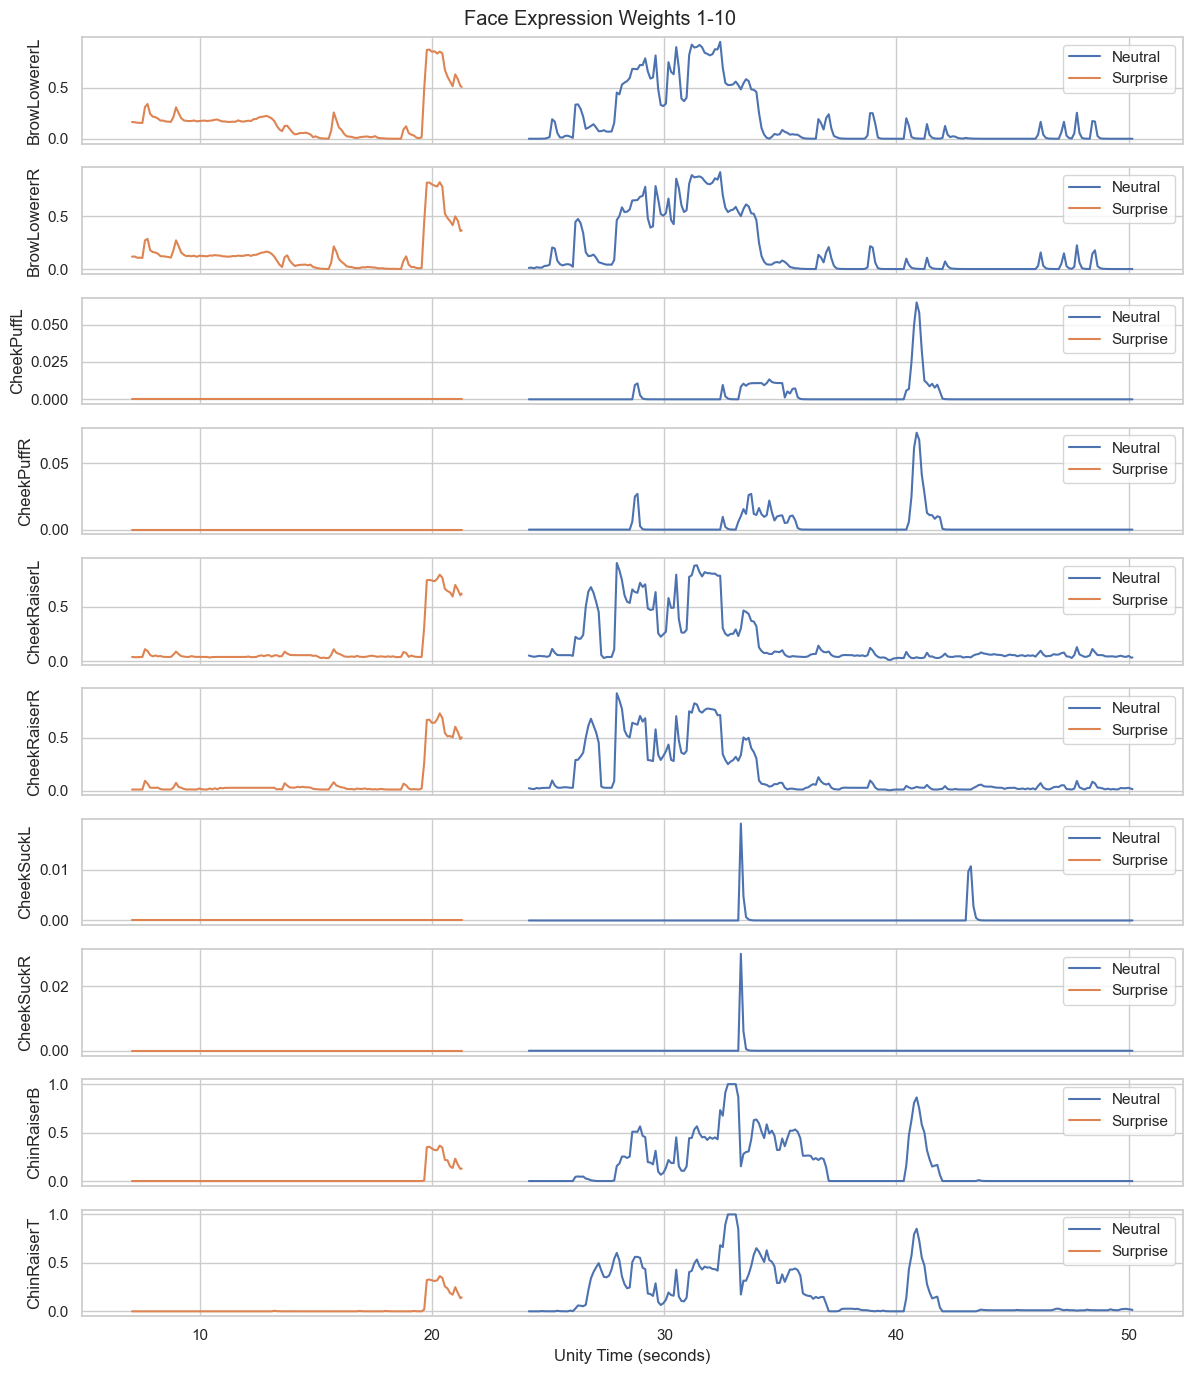

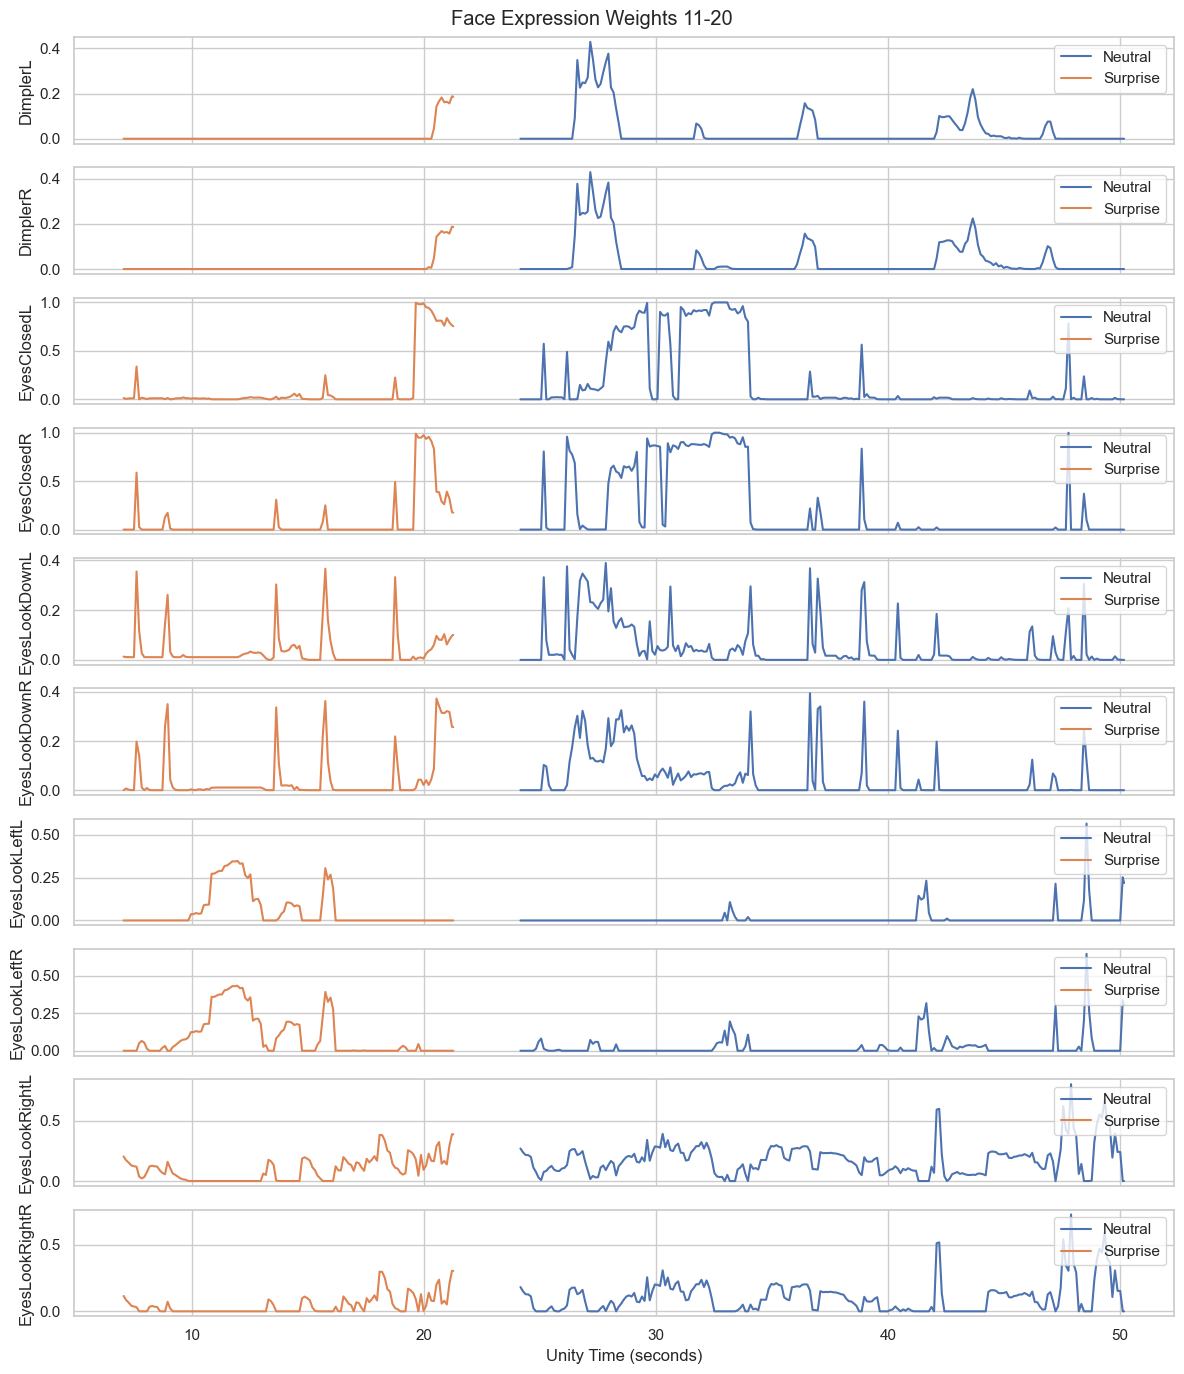

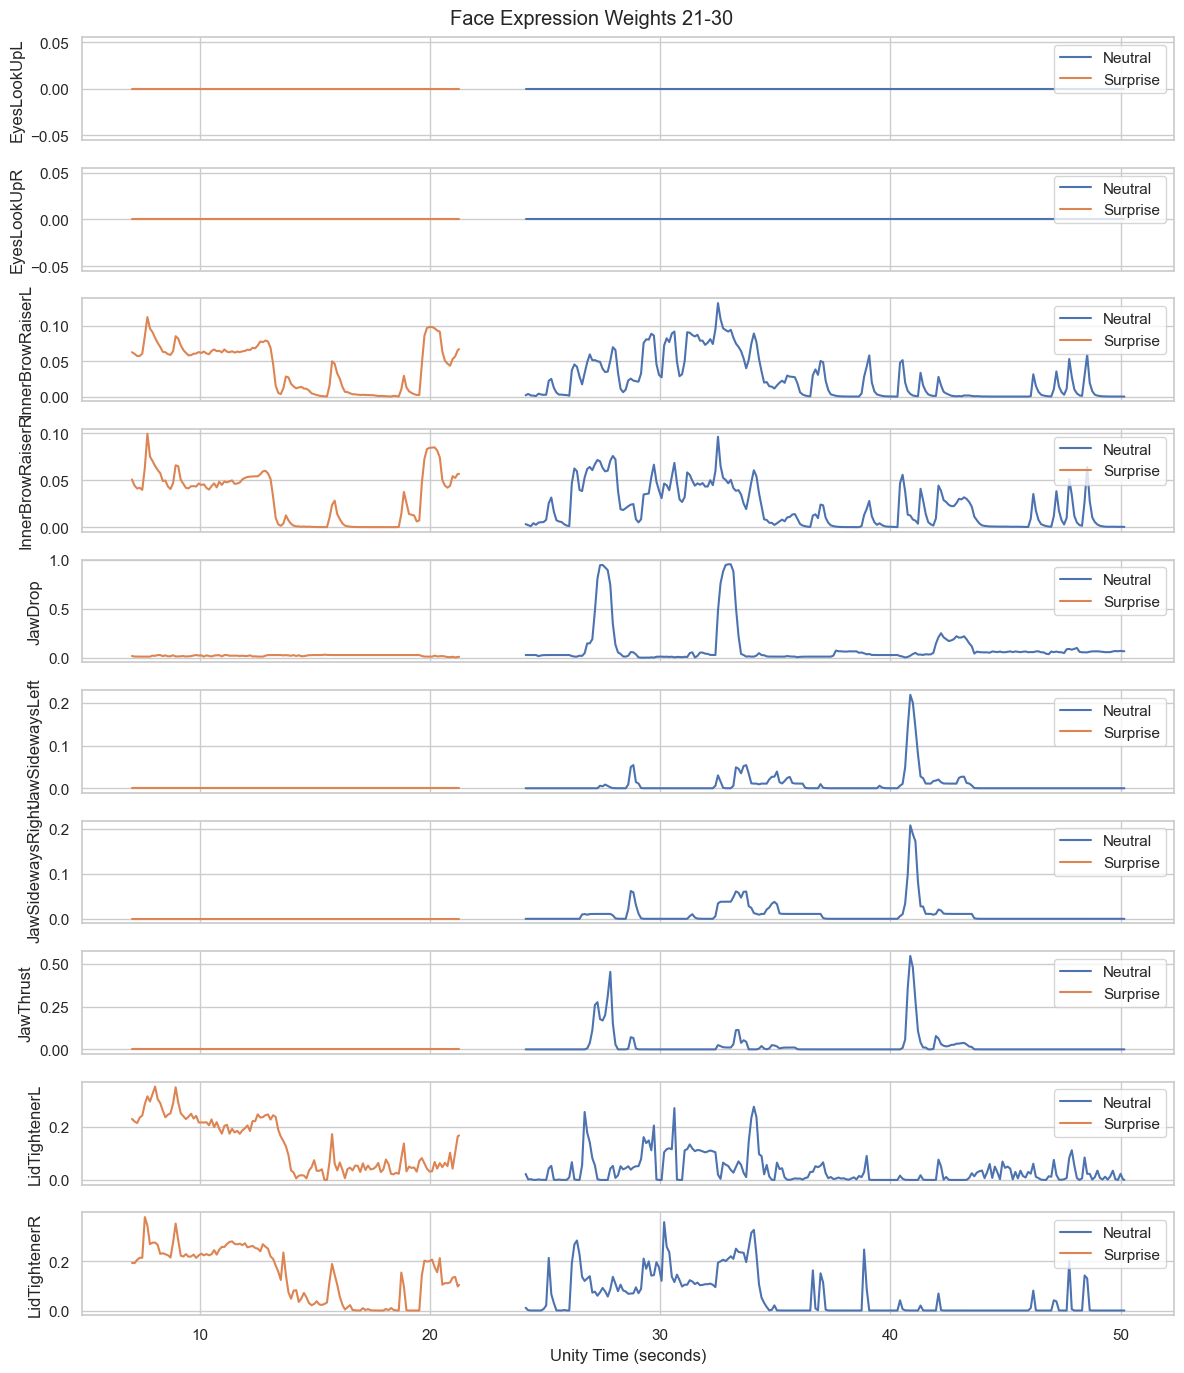

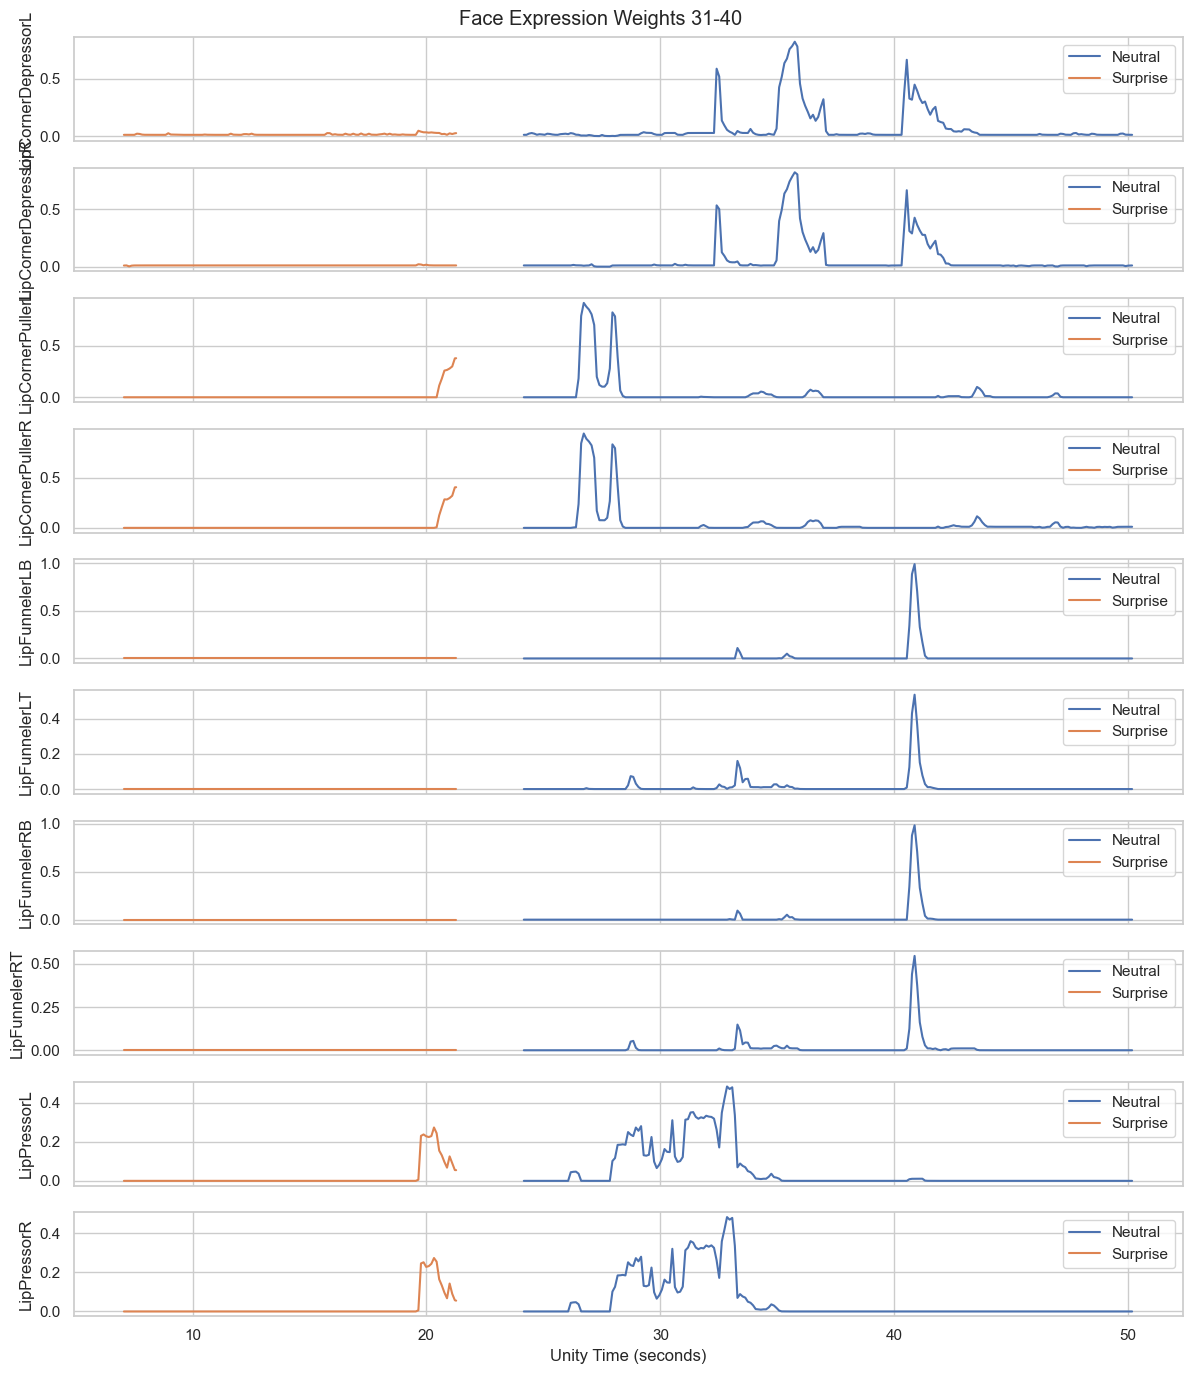

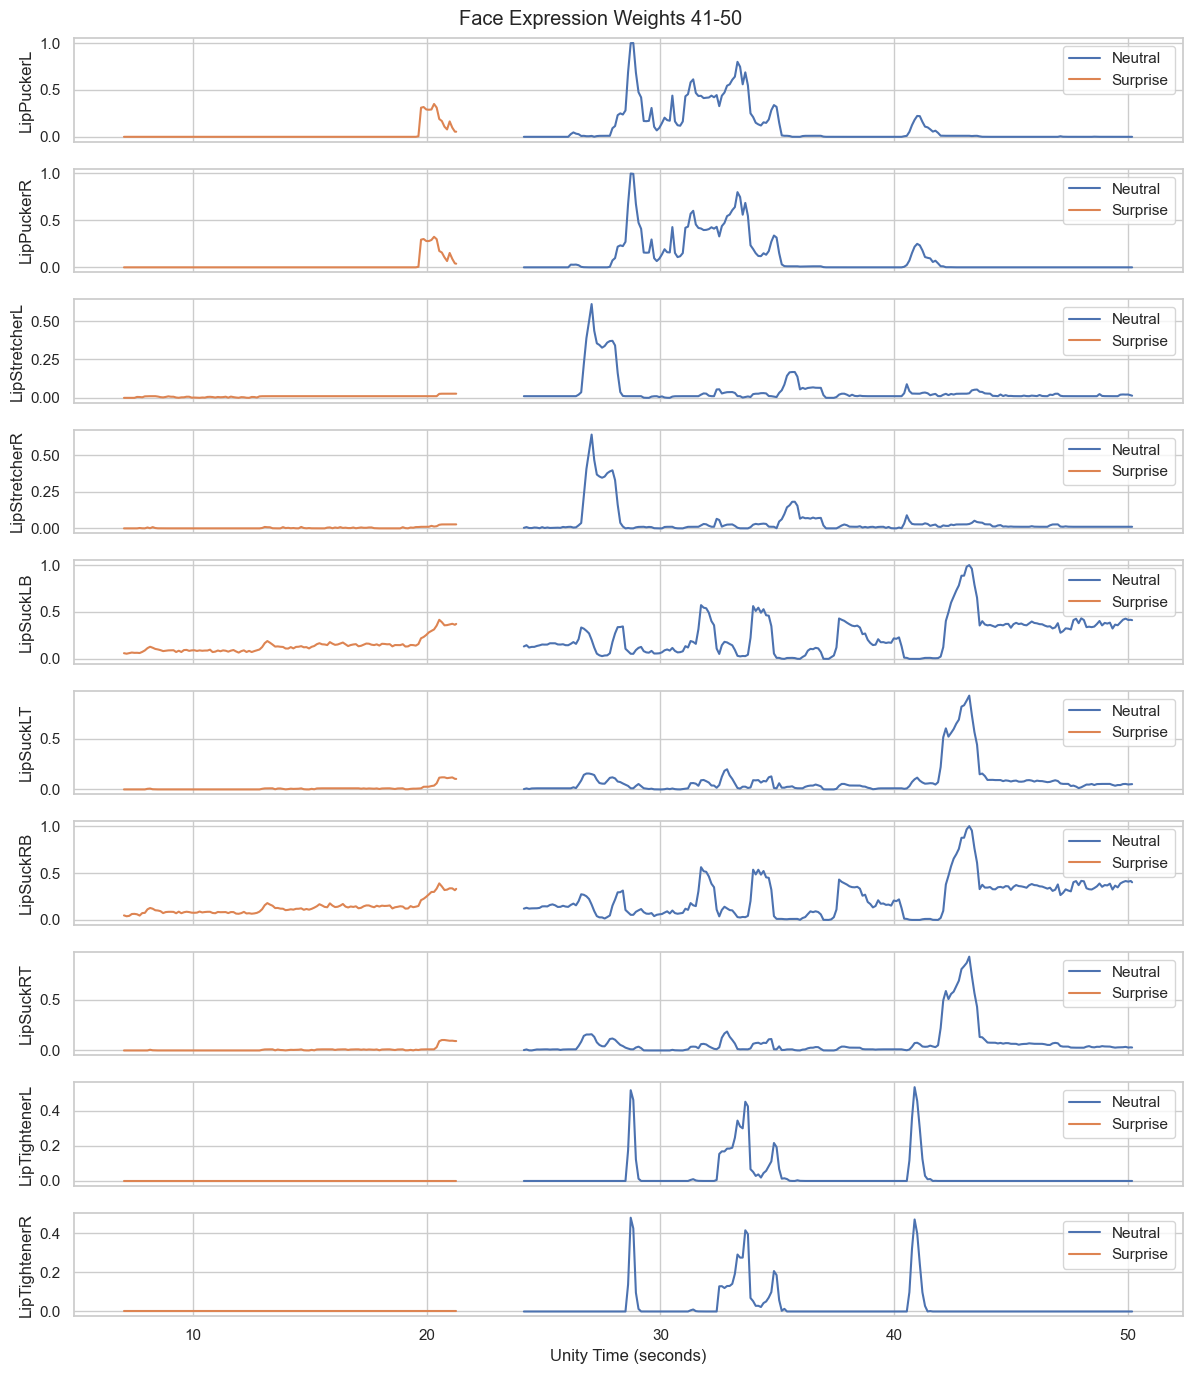

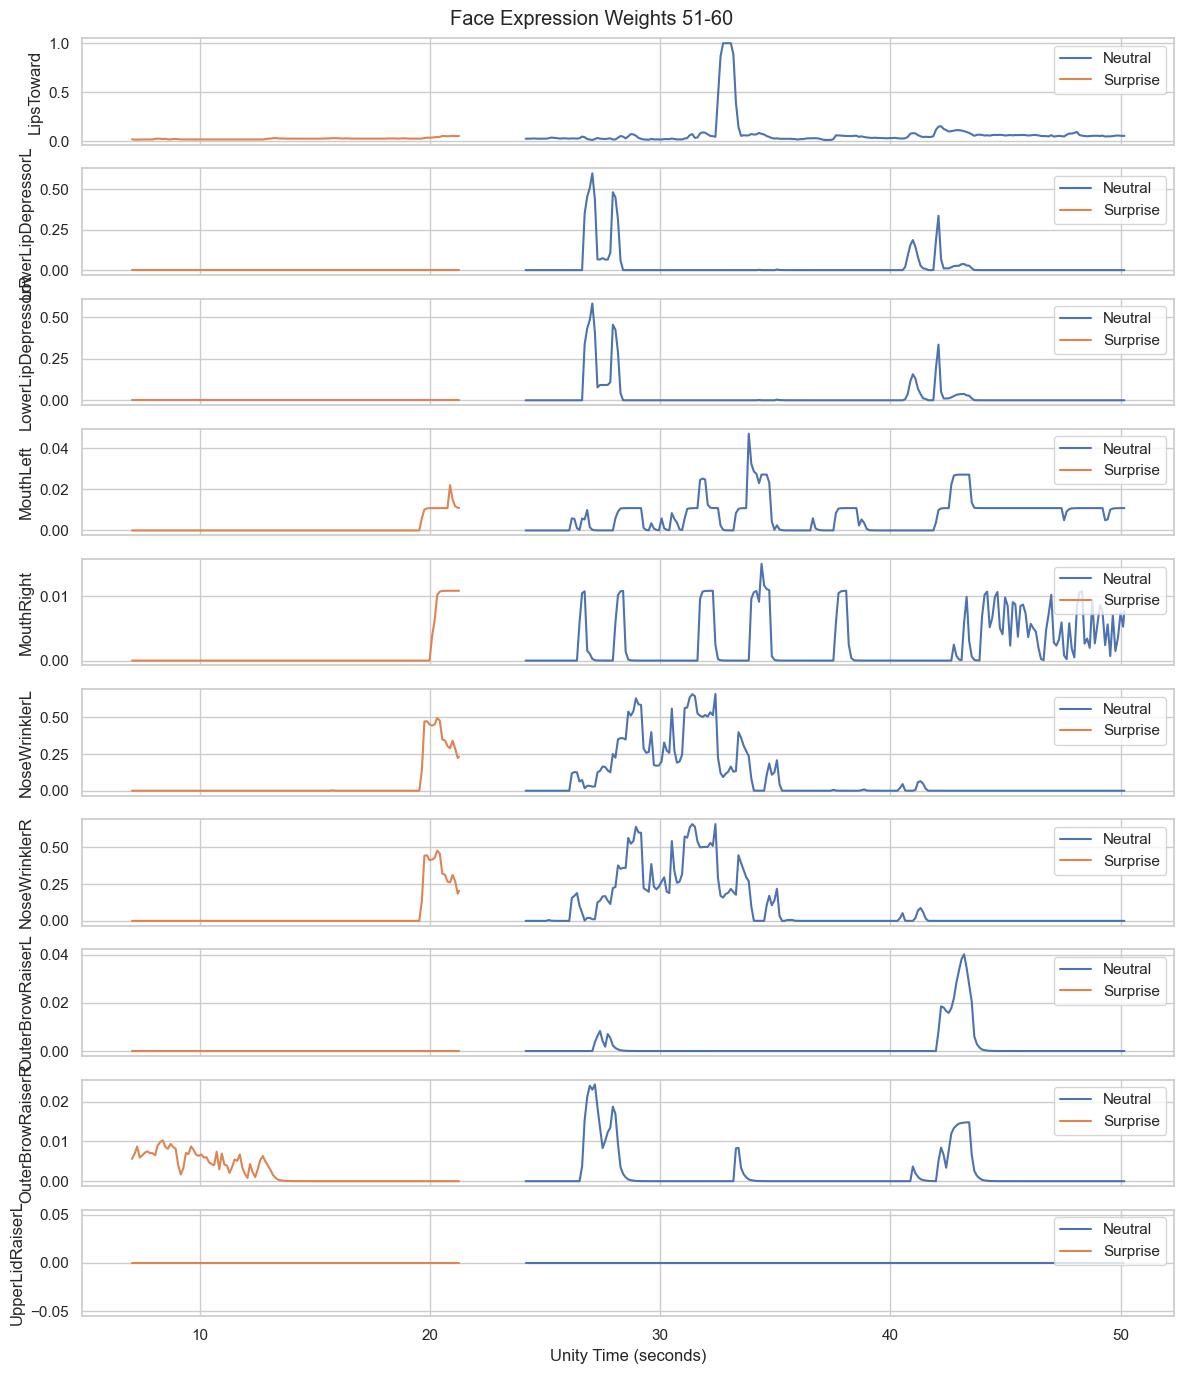

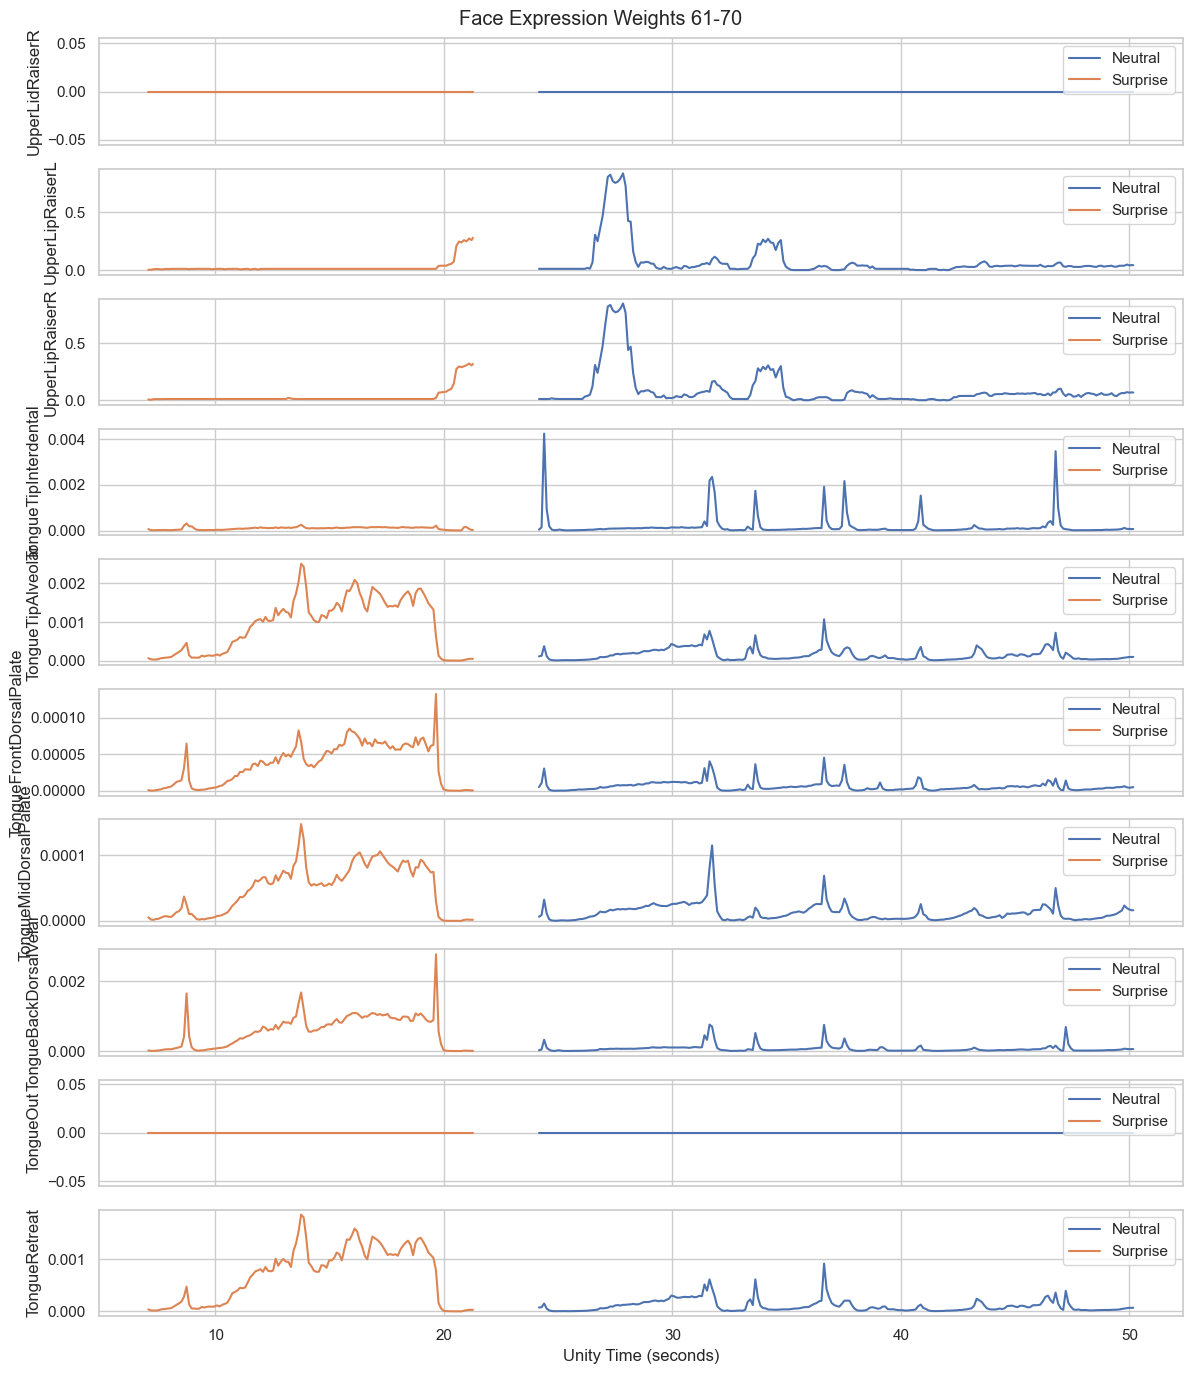

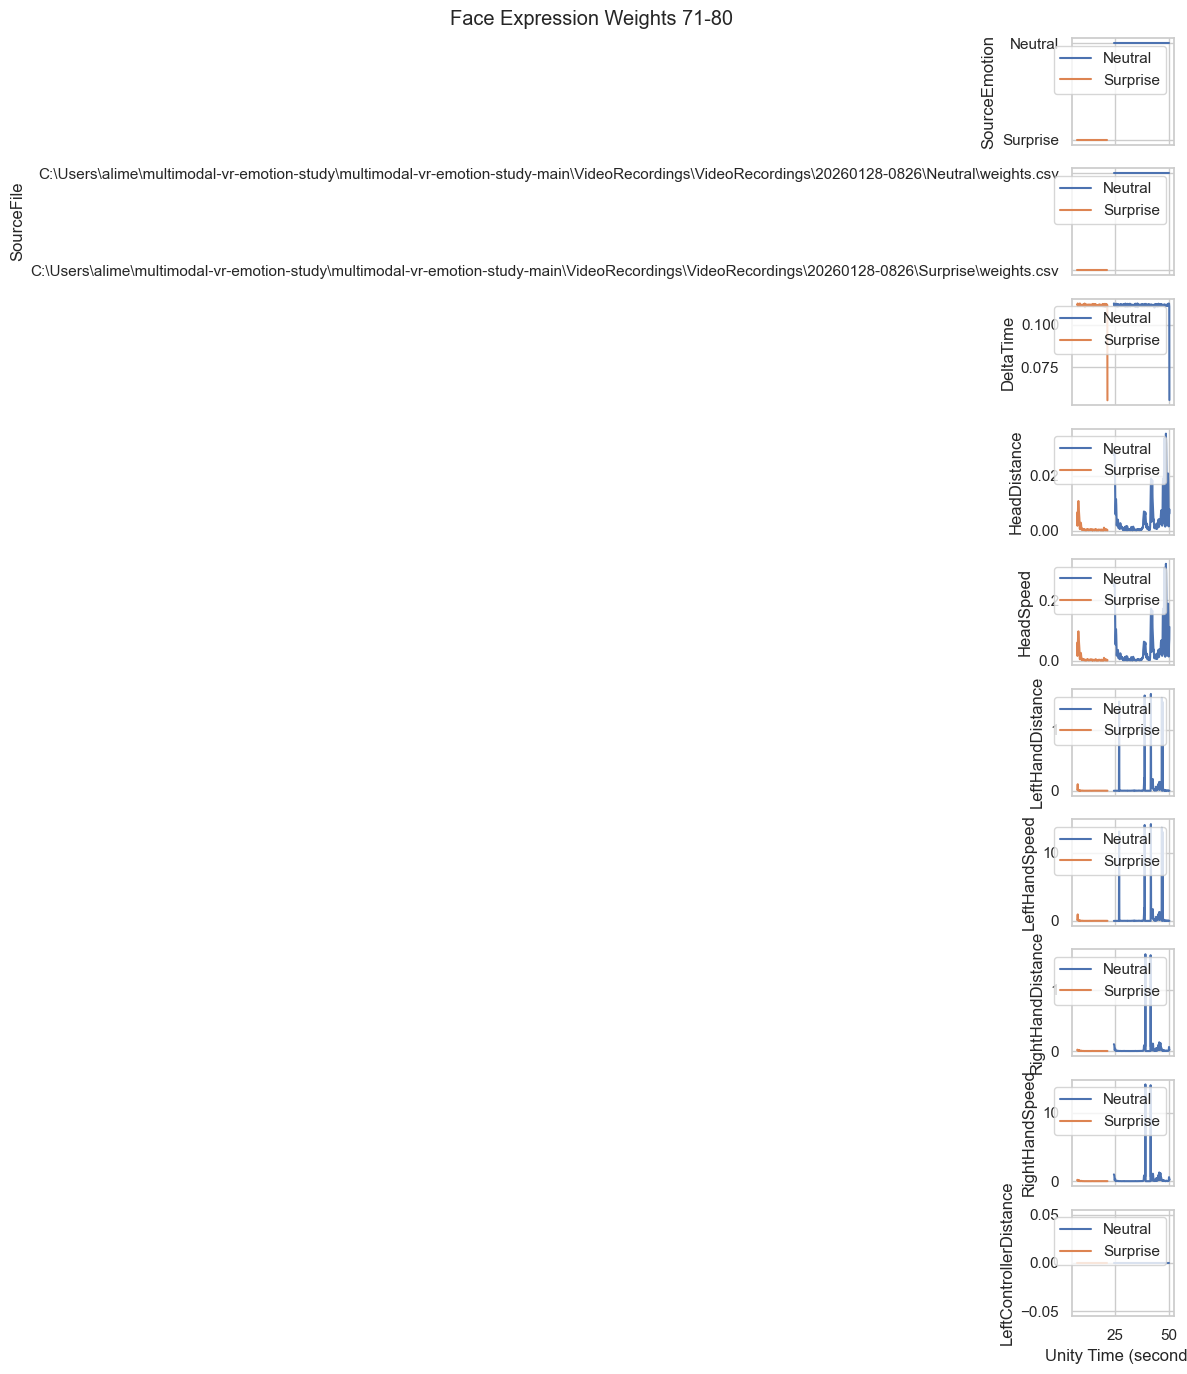

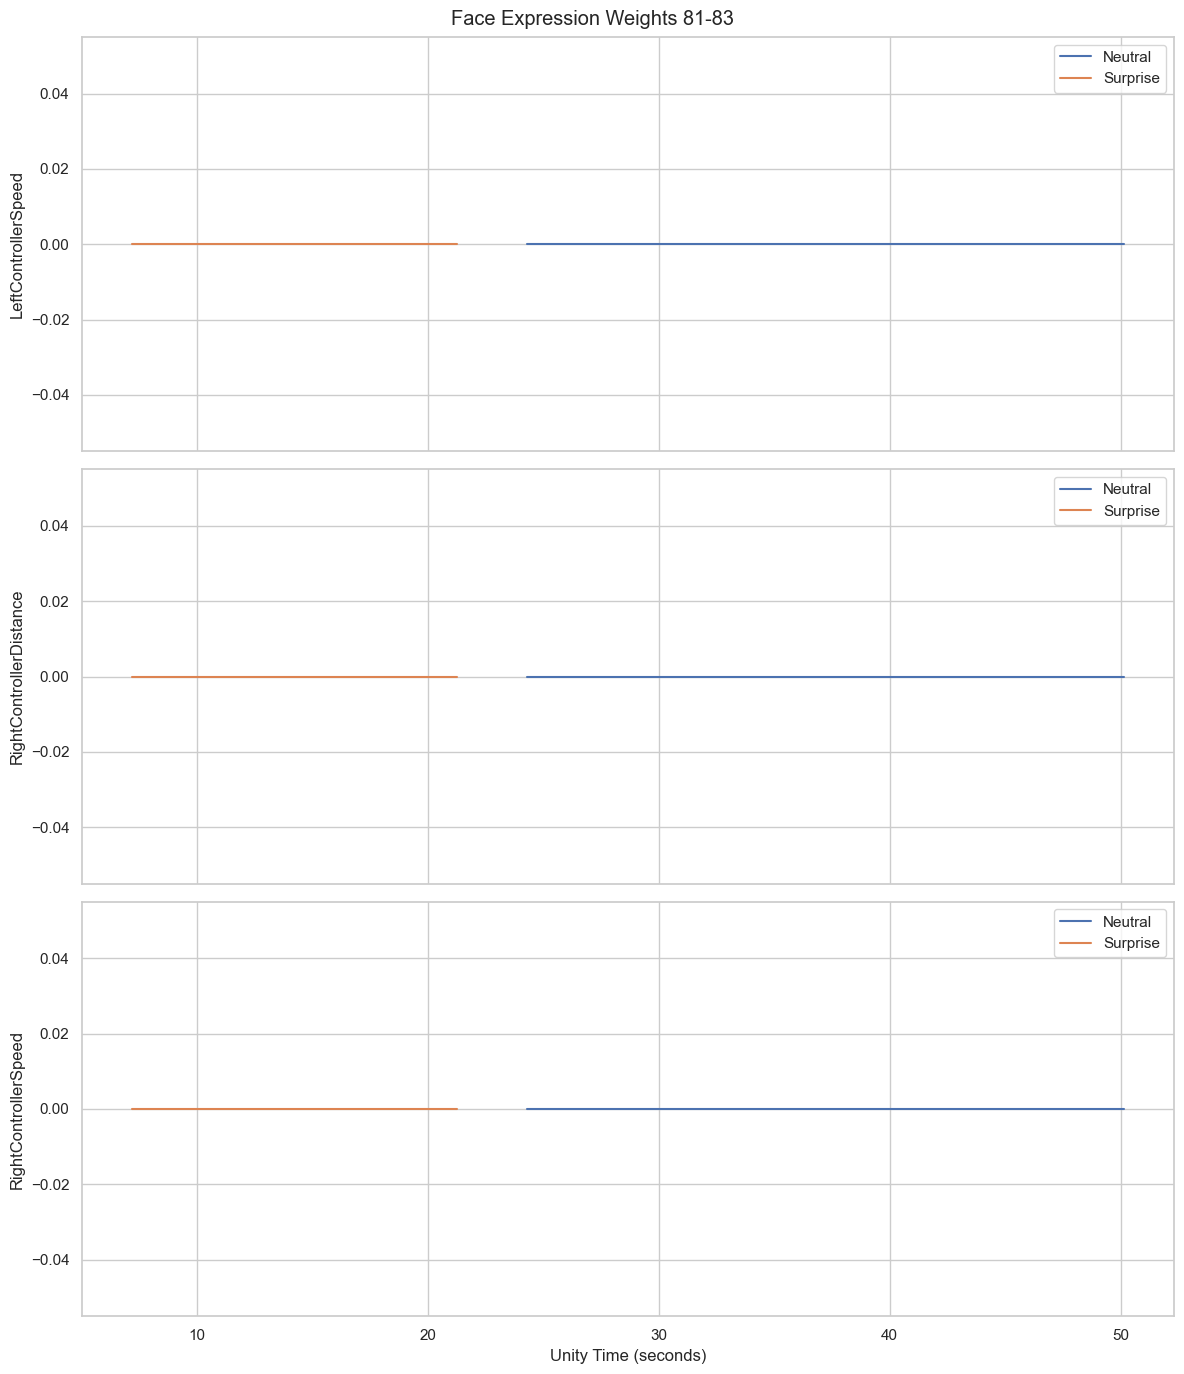

In [6]:
face_columns = motion_df.columns[24:]  # after FaceValid, based on your current CSV

for start in range(0, len(face_columns), 10):
    batch = face_columns[start:start + 10]

    fig, axes = plt.subplots(len(batch), 1, figsize=(12, 14), sharex=True)

    for expression_name, ax in zip(batch, axes):
        sns.lineplot(
            data=motion_df,
            x="Timestamp",
            y=expression_name,
            hue="SourceEmotion",
            ax=ax
        )
        ax.set_ylabel(expression_name)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Unity Time (seconds)")
    fig.suptitle(f"Face Expression Weights {start + 1}-{start + len(batch)}")
    plt.tight_layout()
    plt.show()

## Plot Head Position Over Time

This plot helps confirm that the headset position changes naturally during each emotion recording.


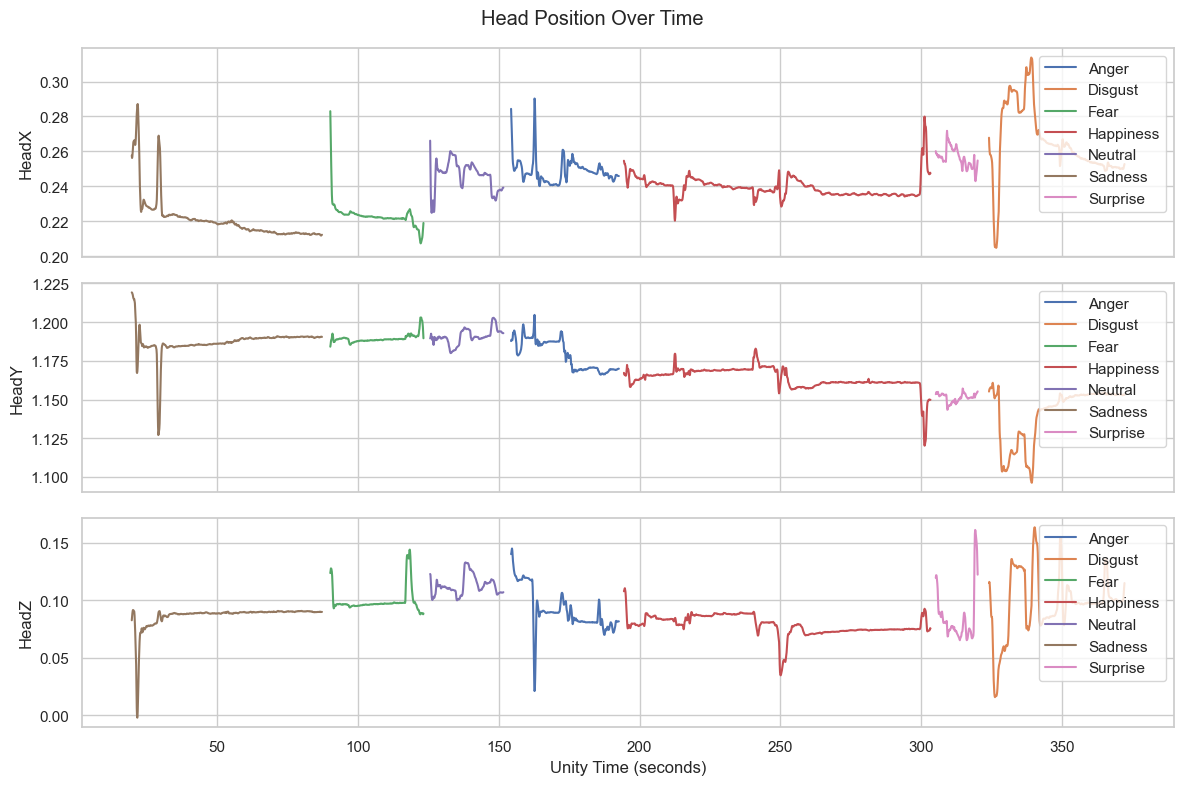

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for axis_name, ax in zip(["HeadX", "HeadY", "HeadZ"], axes):
    sns.lineplot(data=motion_df, x="Timestamp", y=axis_name, hue="SourceEmotion", ax=ax)
    ax.set_ylabel(axis_name)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Unity Time (seconds)")
fig.suptitle("Head Position Over Time")
plt.tight_layout()
plt.show()


## Plot Movement Speed By Emotion

This compares how much movement happened during each emotion video.


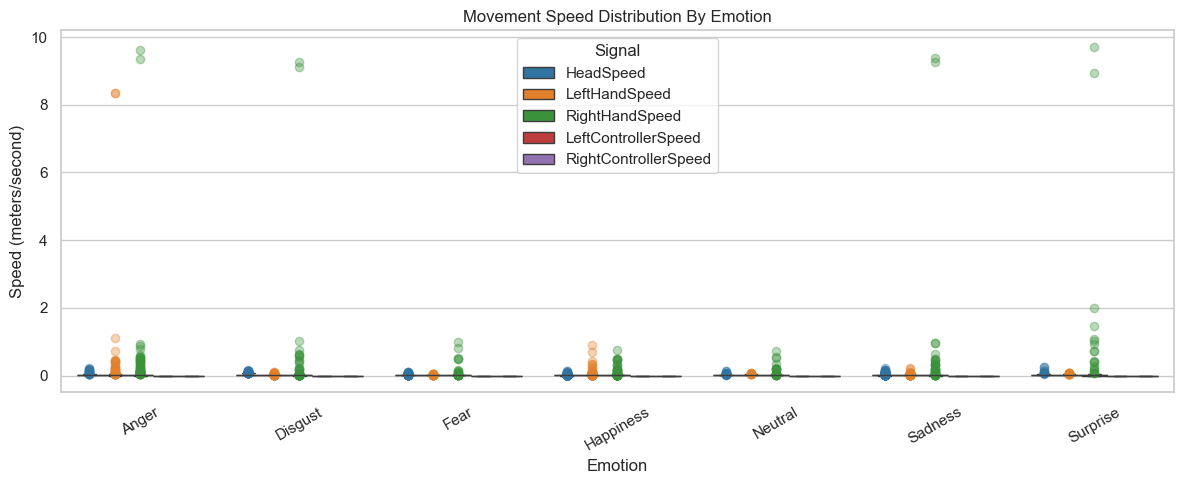

In [7]:
speed_long = motion_df.melt(
    id_vars=["SourceEmotion", "Timestamp"],
    value_vars=[f"{prefix}Speed" for prefix in signal_prefixes if f"{prefix}Speed" in motion_df.columns],
    var_name="Signal",
    value_name="Speed",
)

speed_long = speed_long.replace([np.inf, -np.inf], np.nan).dropna(subset=["Speed"])

signal_palette = {
    "HeadSpeed": "#1f77b4",
    "LeftHandSpeed": "#ff7f0e",
    "RightHandSpeed": "#2ca02c",
    "LeftControllerSpeed": "#d62728",
    "RightControllerSpeed": "#9467bd",
}

hue_order = [signal for signal in signal_palette if signal in speed_long["Signal"].unique()]

plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=speed_long,
    x="SourceEmotion",
    y="Speed",
    hue="Signal",
    hue_order=hue_order,
    palette=signal_palette,
)

# palette colors the boxes; matplotlib still draws outliers in black
for i, flier in enumerate(ax.lines[5::6]):
    color = ax.patches[i].get_facecolor()
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)
    flier.set_color(color)
    flier.set_alpha(0.35)

plt.title("Movement Speed Distribution By Emotion")
plt.xlabel("Emotion")
plt.ylabel("Speed (meters/second)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Export Feature Table

This creates a compact CSV that can be used as a first machine-learning input table: one row per emotion recording.


In [ ]:
OUTPUT_DIR = SESSION_ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

features_path = OUTPUT_DIR / "emotion_motion_features.csv"
features.to_csv(features_path, index=False)

print(features_path)
features
